# World Bank API Analysis

En este proyecto se analiza la evolución socioeconómica y ambiental de cinco países entre 2010 y 2024 utilizando la API del World Bank.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine


In [10]:
url = "https://api.worldbank.org/v2/country"

params = {
    "format": "json",
    "per_page": 5,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()

print("Metadatos:")
print(data[0])

print("\nPrimer país:")
print(data[1][0])

Metadatos:
{'page': 1, 'pages': 60, 'per_page': '5', 'total': 296}

Primer país:
{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


La API del World Bank devuelve una lista donde:

- El primer elemento contiene metadatos (paginación).
- El segundo elemento contiene los datos solicitados.

Esto permite recorrer múltiples páginas para obtener toda la información.

In [17]:
BASE_URL = "https://api.worldbank.org/v2"

countries = ["BEL", "CHL", "CAN", "BTN", "BRA"]

indicators = {
    "population": "SP.POP.TOTL",
    "gdp_per_capita": "NY.GDP.PCAP.CD",
    "renewable_energy": "EG.FEC.RNEW.ZS",
    "life_expectancy": "SP.DYN.LE00.IN"
}

START_YEAR = 2010
END_YEAR = 2024

In [18]:
def fetch_indicator(country, indicator):
    
    data_list = []
    page = 1
    
    while True:
        
        url = f"{BASE_URL}/country/{country}/indicator/{indicator}"
        
        params = {
            "format": "json",
            "per_page": 100,
            "page": page,
            "date": f"{START_YEAR}:{END_YEAR}"
        }
        
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        
        payload = response.json()
        
        if len(payload) < 2:
            break
        
        data = payload[1]
        
        if not data:
            break
        
        for item in data:
            data_list.append({
                "country": item["country"]["value"],
                "year": item["date"],
                "value": item["value"]
            })
        
        if page >= payload[0]["pages"]:
            break
        
        page += 1
    
    return data_list

In [19]:
datasets = {}

for name, code in indicators.items():
    
    all_data = []
    
    for country in countries:
        data = fetch_indicator(country, code)
        print(f"{country} - {name}: {len(data)} datos")
        all_data.extend(data)
    
    df = pd.DataFrame(all_data)
    
    if df.empty:
        print(f"⚠️ No hay datos para {name}")
        continue
    
    # limpieza
    df = df.dropna(subset=["value"])
    df["year"] = df["year"].astype(int)
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values(by="year")
    
    datasets[name] = df

BEL - population: 15 datos
CHL - population: 15 datos
CAN - population: 15 datos
BTN - population: 15 datos
BRA - population: 15 datos
BEL - gdp_per_capita: 15 datos
CHL - gdp_per_capita: 15 datos
CAN - gdp_per_capita: 15 datos
BTN - gdp_per_capita: 15 datos
BRA - gdp_per_capita: 15 datos
BEL - renewable_energy: 15 datos
CHL - renewable_energy: 15 datos
CAN - renewable_energy: 15 datos
BTN - renewable_energy: 15 datos
BRA - renewable_energy: 15 datos
BEL - life_expectancy: 15 datos
CHL - life_expectancy: 15 datos
CAN - life_expectancy: 15 datos
BTN - life_expectancy: 15 datos
BRA - life_expectancy: 15 datos


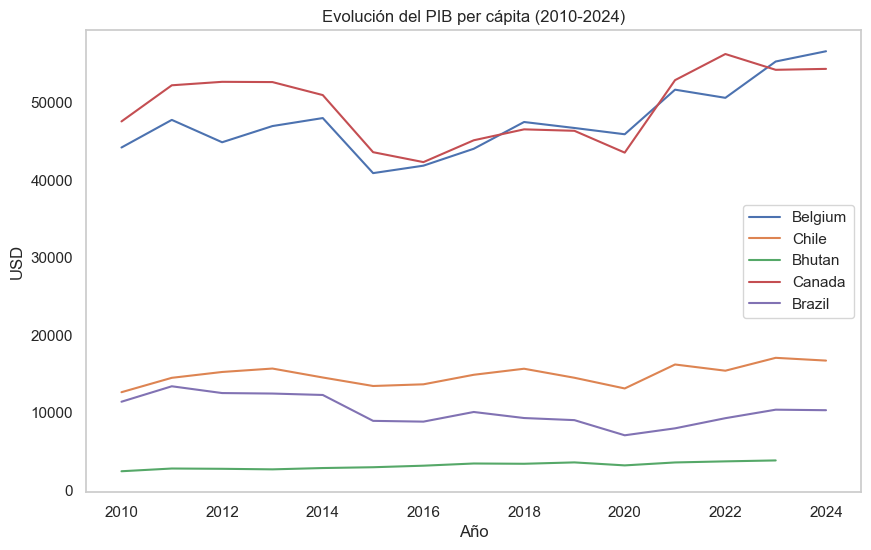

In [28]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

for country in datasets["gdp_per_capita"]["country"].unique():
    
    subset = datasets["gdp_per_capita"][
        datasets["gdp_per_capita"]["country"] == country
    ]
    
    plt.plot(subset["year"], subset["value"], label=country)

plt.title("Evolución del PIB per cápita (2010-2024)")
plt.xlabel("Año")
plt.ylabel("USD")
plt.legend()
plt.grid()
plt.show()

Se observa que Canadá y Bélgica presentan los niveles más altos de PIB per cápita. 
Brasil y Chile muestran crecimiento progresivo, mientras que Bután mantiene valores más bajos.

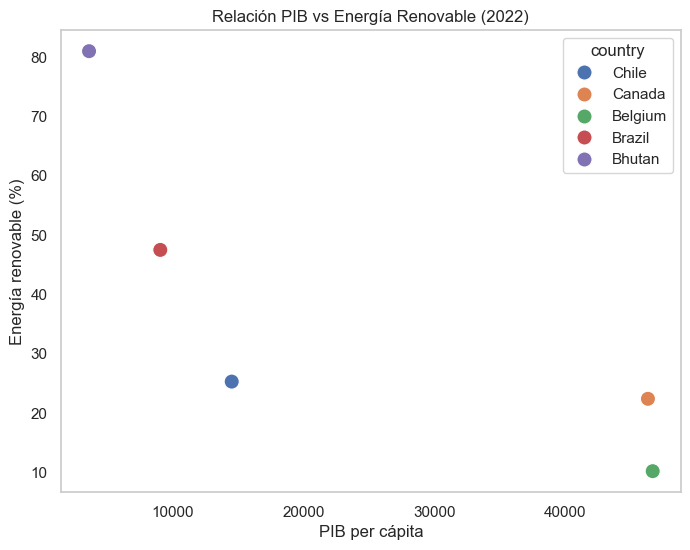

In [29]:
year = 2019
sns.set(style="whitegrid")
gdp = datasets["gdp_per_capita"]
renew = datasets["renewable_energy"]

merge_df = pd.merge(
    gdp[gdp["year"] == year],
    renew[renew["year"] == year],
    on="country",
    suffixes=("_gdp", "_renew")
)

# eliminar posibles nulos
merge_df = merge_df.dropna()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merge_df,
    x="value_gdp",
    y="value_renew",
    hue="country",
    s=120
)

plt.title("Relación PIB vs Energía Renovable (2022)")
plt.xlabel("PIB per cápita")
plt.ylabel("Energía renovable (%)")
plt.grid()
plt.show()

Debido a la disponibilidad limitada de datos en años recientes, se utilizó el año 2019 para garantizar la comparación entre todos los países.

In [25]:
engine = create_engine("sqlite:///world_bank_analysis.db")

for name, df in datasets.items():
    df.to_sql(name, engine, if_exists="replace", index=False)

In [27]:
pd.read_sql("SELECT * FROM gdp_per_capita LIMIT 25", engine)

,country,year,value
0,Belgium,2010,44197.393671
1,Chile,2010,12632.870472
2,Bhutan,2010,2435.579806
3,Canada,2010,47560.666601
4,Brazil,2010,11403.284004
5,Canada,2011,52223.858840
6,Chile,2011,14487.392783
7,Bhutan,2011,2787.979676
8,Brazil,2011,13396.626316
9,Belgium,2011,47760.829878


## Conclusiones

- Se evidenció un crecimiento económico general en los países analizados a lo largo del periodo 2010–2024, especialmente en Canadá y Bélgica.

- La relación entre el PIB per cápita y el uso de energías renovables no es completamente directa, ya que algunos países con mayor desarrollo económico presentan menor proporción de energías limpias, lo que indica dependencia de fuentes tradicionales.

- Países como Bután destacan por un alto porcentaje de uso de energías renovables, lo que refleja un enfoque más sostenible en su desarrollo.

- Se identificaron valores faltantes en algunos indicadores, especialmente en años recientes, lo que limitó ciertos análisis comparativos.

- La API del World Bank permite acceder a datos estructurados y confiables, facilitando el análisis de variables socioeconómicas y ambientales entre distintos países.

### Limitaciones del indicador de emisiones de CO₂

Durante el análisis del indicador de emisiones de CO₂ per cápita, se evidenció una disponibilidad limitada de datos para algunos países seleccionados.

En particular, países como Bután presentan escasa o nula información en este indicador, lo que impide su integración en ciertos análisis visuales y comparativos. Asimismo, se identificó que los datos más recientes no siempre están disponibles, lo que reduce la consistencia temporal del estudio.

Debido a estas limitaciones, el indicador de CO₂ no fue considerado como variable principal en el análisis final, optándose por el uso de indicadores alternativos con mayor cobertura y consistencia, como el porcentaje de uso de energías renovables.

Este hallazgo resalta la importancia de evaluar la calidad y disponibilidad de los datos antes de realizar análisis comparativos, especialmente cuando se trabaja con fuentes abiertas y globales.